In [4]:
import numpy as np
import pandas as pd
import re
import nltk

In [5]:
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
from google.colab import files
uploaded=files.upload()

Saving Heart_disease.csv.csv to Heart_disease.csv (1).csv


In [14]:
df = pd.read_csv("Heart_disease.csv (1).csv")
print("Dataset loaded successfully!")

Dataset loaded successfully!


In [17]:
print("First 5 rows:")
display(df.head())
print("\nDataser Shape:",df.shape)
print("\nColoumn Names:",df.columns)
print("\nDataser Information:")
df.info()
print("\nSentiment Distribution:")
print(df["target"].value_counts())

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1



Dataser Shape: (303, 14)

Coloumn Names: Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

Dataser Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3

In [18]:
nltk.download("stopwords")
print("Stopwords downloaded successfully!")

Stopwords downloaded successfully!


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [26]:
corpus=[]
ps=PorterStemmer()
english_stopwords=set(stopwords.words("english"))
for i in range(len(df)):
  thal=re.sub("[^a-zA-Z]","",str(df["thal"].iloc[i])).lower()
  words=thal.split()
  words=[w for w in words if w not in english_stopwords]
  words=[ps.stem(w)for w in words]
  corpus.append(" ".join(words))
print("POreprocessing completed!")
print("\nFirst 10 processed thal:")
print(corpus[:10])

POreprocessing completed!

First 10 processed thal:
['', '', '', '', '', '', '', '', '', '']


In [35]:
x=df.iloc[:,:-1].values
y=df.iloc[:,-1].values
print("Feature matrix shape:",x.shape)
print("Target shape:",y.shape)

Feature matrix shape: (303, 13)
Target shape: (303,)


In [62]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=4)
print("Training set shape:",x_train.shape)
print("Testing set shape:",x_test.shape)

Training set shape: (242, 13)
Testing set shape: (61, 13)


In [63]:
model=RandomForestClassifier(n_estimators=35,random_state=42)
model.fit(x_train,y_train)
print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [ ]:
model_score=model.score(x_test,y_test)
print("Model Accuracy:",round(model_score*100,2),"%")
y_pred=model.predict(x_test)
print("Predictions completed!")

In [64]:
score1=accuracy_score(y_test,y_pred)
score2=precision_score(y_test,y_pred,zero_division=0)
score3=recall_score(y_test,y_pred,zero_division=0)
print("---Scores---")
print("Accuracy:",round(score1*100,2),"%")
print("Precision:",round(score2,2))
print("Recall:",round(score3,2))

---Scores---
Accuracy: 85.25 %
Precision: 0.86
Recall: 0.89


In [65]:
print("Classification Report")
print(classification_report(y_test,y_pred,zero_division=0))

Classification Report
              precision    recall  f1-score   support

           0       0.83      0.80      0.82        25
           1       0.86      0.89      0.88        36

    accuracy                           0.85        61
   macro avg       0.85      0.84      0.85        61
weighted avg       0.85      0.85      0.85        61



Confusion Matrix:


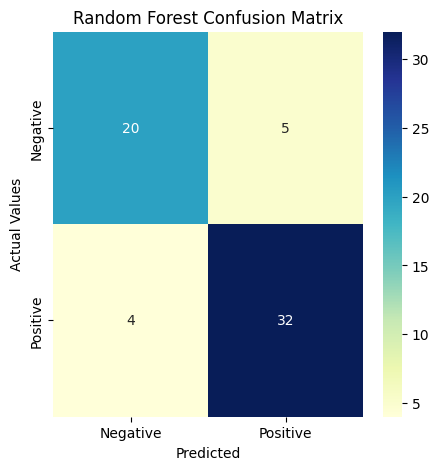

In [66]:
cm=confusion_matrix(y_test,y_pred)
print("Confusion Matrix:")
plt.figure(figsize=(5,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="YlGnBu",
    xticklabels=["Negative","Positive"],
    yticklabels=["Negative","Positive"]
    )
plt.xlabel("Predicted")
plt.ylabel("Actual Values")
plt.title("Random Forest Confusion Matrix")
plt.show()


In [67]:
best_accuracy=0
n_estimators_val=5
print("Testing different n_estimators values...\n")
for i in np.arange(1,30,2):
  temp_model=RandomForestClassifier(n_estimators=i,random_state=42)
  temp_model.fit(x_train,y_train)
  temp_pred=temp_model.predict(x_test)
  score=accuracy_score(y_test,temp_pred)
  print("n_estimators=",i,"Accuracy=",round(score*100,2),"%")
  if score>best_accuracy:
    best_accuracy=score
    n_estimators_val=i
print("Best accuracy:",round(best_accuracy*100,2),"%","with n_estimators=",n_estimators_val)

Testing different n_estimators values...

n_estimators= 1 Accuracy= 83.61 %
n_estimators= 3 Accuracy= 83.61 %
n_estimators= 5 Accuracy= 88.52 %
n_estimators= 7 Accuracy= 90.16 %
n_estimators= 9 Accuracy= 83.61 %
n_estimators= 11 Accuracy= 86.89 %
n_estimators= 13 Accuracy= 81.97 %
n_estimators= 15 Accuracy= 81.97 %
n_estimators= 17 Accuracy= 81.97 %
n_estimators= 19 Accuracy= 81.97 %
n_estimators= 21 Accuracy= 85.25 %
n_estimators= 23 Accuracy= 83.61 %
n_estimators= 25 Accuracy= 85.25 %
n_estimators= 27 Accuracy= 88.52 %
n_estimators= 29 Accuracy= 88.52 %
Best accuracy: 90.16 % with n_estimators= 7


In [68]:
model=RandomForestClassifier(n_estimators=n_estimators_val,random_state=42)
model.fit(x_train,y_train)
print("Optimized Random Forest Model:")
print(model)

Optimized Random Forest Model:
RandomForestClassifier(n_estimators=np.int64(7), random_state=42)


In [69]:
def predict_sentiment(sample_text):
  data=np.array(sample_text).reshape(1,-1)
  prediction=model.predict(data) [0]
  return prediction
sample_patient=[57,1,3,145,233,1,0,150,0,2.,0,0,1]
prediction=predict_sentiment(sample_patient)
print("Patient Health Data Summary Provided.")
if prediction==1:
  print("Prediction: The model detects a risk of Heart disease.")
else:
  print("Prediction: The model indicates No reisk of heart disease.")

Patient Health Data Summary Provided.
Prediction: The model detects a risk of Heart disease.


In [71]:
final_predictions=model.predict(x_test)
accuracy=accuracy_score(y_test,final_predictions)
precision=precision_score(y_test,final_predictions,zero_division=0)
recall=recall_score(y_test,final_predictions)
print("\n========================")
print("FINAL RANDOM FOREST MODEL PERFORMANCE")
print("\n========================")
print("Accuracy:",round(accuracy*100,2),"%")
print("Precision:",round(recall,2))
print("Best n_estimators:",n_estimators_val)


FINAL RANDOM FOREST MODEL PERFORMANCE

Accuracy: 90.16 %
Precision: 0.92
Best n_estimators: 7
